# COVID-19 Exploratory Data Analysis

#### This notebook explores the cleaned COVID-19 dataset and investigates
#### the research questions defined for the project.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(
    "../data/processed/covid_cleaned.csv",
    parse_dates=["Date"]
)

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Data Inconsistent
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,False
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe,False
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa,False
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe,False
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa,False


In [7]:
country_df = (
    df.groupby(["Country/Region", "Date"], as_index=False)[
        ["Confirmed", "Deaths", "Recovered", "Active"]
    ]
    .sum()
)

In [10]:
country_df

,Country/Region,Date,Confirmed,Deaths,Recovered,Active
0,Afghanistan,2020-01-22,0,0,0,0
1,Afghanistan,2020-01-23,0,0,0,0
2,Afghanistan,2020-01-24,0,0,0,0
3,Afghanistan,2020-01-25,0,0,0,0
4,Afghanistan,2020-01-26,0,0,0,0
...,...,...,...,...,...,...
35151,Zimbabwe,2020-07-23,2124,28,510,1586
35152,Zimbabwe,2020-07-24,2296,32,514,1750
35153,Zimbabwe,2020-07-25,2434,34,518,1882
35154,Zimbabwe,2020-07-26,2512,34,518,1960


## Q1 — How did COVID-19 cases change globally over time?

In [13]:
daily_totals = (
    country_df.groupby('Date', as_index=False)[
        ["Confirmed", "Deaths", "Recovered", "Active"]
    ]
    .sum()
)

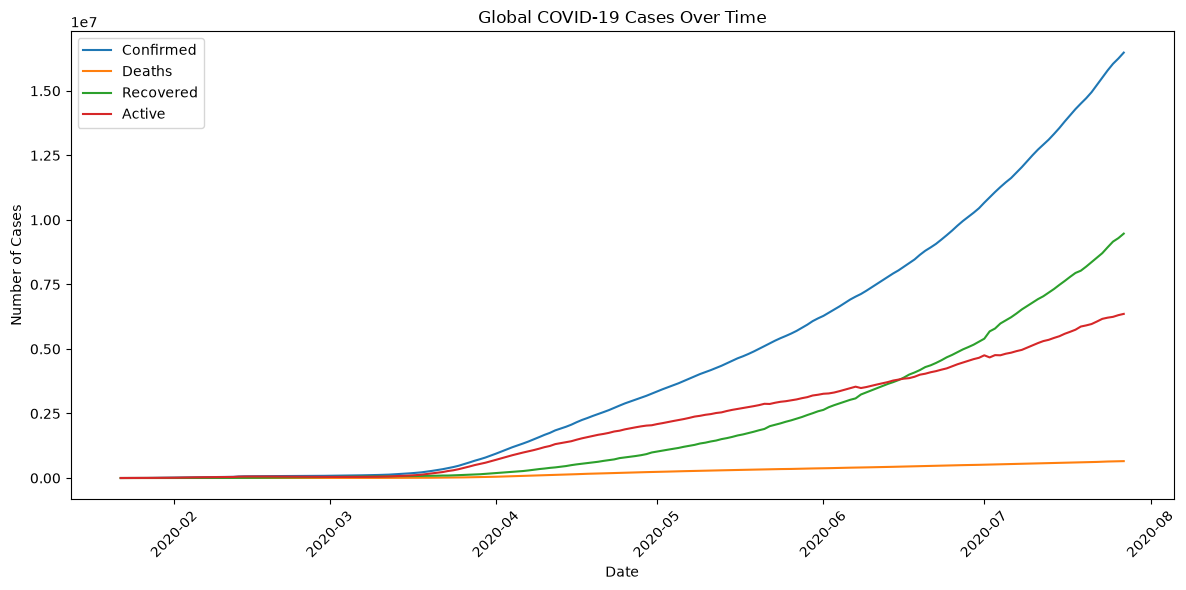

In [17]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_totals['Date'],
    daily_totals['Confirmed'],
    label='Confirmed'
)

plt.plot(
    daily_totals['Date'],
    daily_totals['Deaths'],
    label='Deaths'
)

plt.plot(
    daily_totals['Date'],
    daily_totals['Recovered'],
    label='Recovered'
)

plt.plot(
    daily_totals['Date'],
    daily_totals['Active'],
    label='Active'
)

plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.title('Global COVID-19 Cases Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [18]:
daily_totals["New Confirmed"] = daily_totals["Confirmed"].diff()

In [19]:
daily_totals.head()

,Date,Confirmed,Deaths,Recovered,Active,New Confirmed
0,2020-01-22,555,17,28,510,NaN
1,2020-01-23,654,18,30,606,99.0
2,2020-01-24,941,26,36,879,287.0
3,2020-01-25,1434,42,39,1353,493.0
4,2020-01-26,2118,56,52,2010,684.0


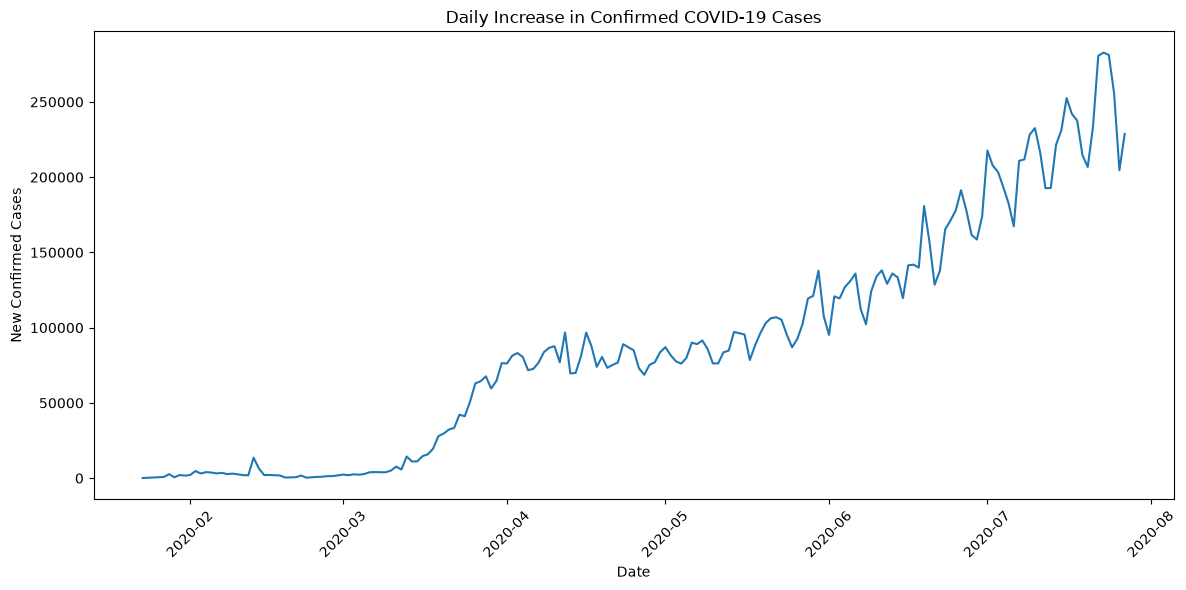

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_totals['Date'],
    daily_totals['New Confirmed']
)

plt.xlabel('Date')
plt.ylabel('New Confirmed Cases')
plt.title('Daily Increase in Confirmed COVID-19 Cases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Q1 Findings

The analysis shows how the cumulative number of confirmed cases,
deaths, recovered cases, and active cases changed throughout the
period from January 22, 2020 to July 27, 2020.

The daily increase in confirmed cases also shows how the pace of
reported infections changed during the period.

## Q1 — How did COVID-19 cases change globally over time?